A movie production company wants to understand how audience feel about a new movie based on social media discussions and reviews.

To achieve this, the company plans to:

Collect social media posts and public reviews of the movie.
Analyze sentiment to determine whether opinions are positive, negative, or neutral.
Identify trending topics and themes around the movie.

In [1]:
import warnings
warnings.filterwarnings('ignore')

In [2]:
%pip install selenium webdriver-manager pandas

Note: you may need to restart the kernel to use updated packages.


In [3]:
from selenium import webdriver
from selenium.webdriver.common.by import By
from selenium.webdriver.chrome.service import Service
from webdriver_manager.chrome import ChromeDriverManager
import time
import pandas as pd

In [4]:
# Setup Chrome
options = webdriver.ChromeOptions()
options.add_argument("--start-maximized")
driver  = webdriver.Chrome(service = Service(ChromeDriverManager().install()), options=options)


In [5]:
url = "https://www.youtube.com/watch?v=HhesaQXLuRY"
driver.get(url)
time.sleep(5)

In [6]:
# Scroll to load comments section
driver.execute_script("window.scrollTo(0,800);")
time.sleep(3)


In [7]:
# scroll mulitple times to load more comments
for i in range(10):
    driver.execute_script("window.scrollBy(0,1000);")
    time.sleep(3)

In [8]:
# extract comments
comments = driver.find_elements(By.XPATH, '//*[@id="content-text"]')

comment_list = []
for comment in comments:
    comment_list.append(comment.text)

In [9]:
driver.quit()
df = pd.DataFrame(comment_list, columns=["Comment"])
df.head()

,Comment
0,"Hank : "" Get a little excitement in your life""..."
1,"If you haven't seen this, you've literally mis..."
2,You know the business and i know the chemistry..
3,Me watching trailer after completing series
4,If you haven't seen breaking bad your eyes are...


In [10]:
print("Total comments Collected: ", len(df))
df.tail(10)

Total comments Collected:  80


,Comment
70,Who is watching this in quarantine?
71,After reading the comments i went and gave thi...
72,I decided to watch this while recovering from ...
73,I wish I could watch this again for the first ...
74,2019 and still literally the best series ever ...
75,I've just finished the First season within 24h...
76,i love how in the ending the first two letters...
77,Most worth watching show of my life.
78,Watching this after knowing how it will end ju...
79,This is one of my absolute favorite series eve...


In [11]:
%pip install nltk textblob wordcloud matplotlib


Note: you may need to restart the kernel to use updated packages.


In [12]:
import nltk
nltk.download('stopwords')
import re
from nltk.corpus import stopwords

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\jenis\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [13]:
stop_words = set(stopwords.words("english"))

def clean_text(text):
    text = text.lower()
    text = re.sub(r"http\S+", "", text) # remove links
    text = re.sub(r"[^a-zA-Z\s]", "", text) # remove special characters
    words = text.split()
    words = [word for word in words if word not in stop_words]
    return " ".join(words)

In [14]:
df["Cleaned"] = df["Comment"].apply(clean_text)
df.head(5)


,Comment,Cleaned
0,"Hank : "" Get a little excitement in your life""...",hank get little excitement life worst advice e...
1,"If you haven't seen this, you've literally mis...",havent seen youve literally missed greatest tv...
2,You know the business and i know the chemistry..,know business know chemistry
3,Me watching trailer after completing series,watching trailer completing series
4,If you haven't seen breaking bad your eyes are...,havent seen breaking bad eyes still virgin


In [15]:
from textblob import TextBlob

def get_sentiment(text):
    polarity = TextBlob(text).sentiment.polarity
    if polarity > 0:
        return "Positive"
    elif polarity < 0:
        return "Negative"
    else:
        return "Neutral"

In [16]:
df["sentiment"] = df["Cleaned"].apply(get_sentiment)
df.head()

,Comment,Cleaned,sentiment
0,"Hank : "" Get a little excitement in your life""...",hank get little excitement life worst advice e...,Negative
1,"If you haven't seen this, you've literally mis...",havent seen youve literally missed greatest tv...,Positive
2,You know the business and i know the chemistry..,know business know chemistry,Neutral
3,Me watching trailer after completing series,watching trailer completing series,Neutral
4,If you haven't seen breaking bad your eyes are...,havent seen breaking bad eyes still virgin,Negative


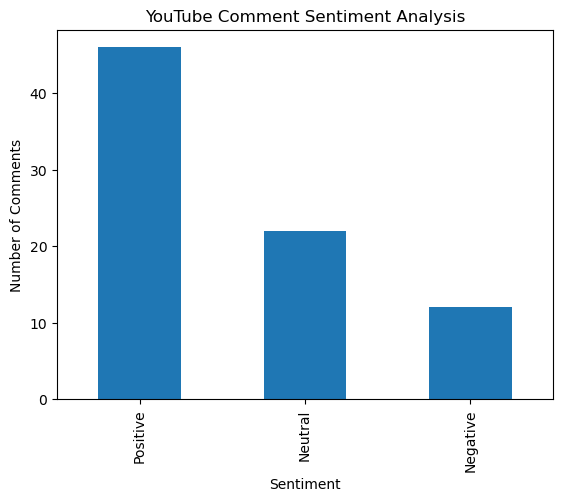

In [17]:
import matplotlib.pyplot as plt

sentiment_counts = df["sentiment"].value_counts()
sentiment_counts.plot(kind="bar")
plt.title("YouTube Comment Sentiment Analysis")
plt.xlabel("Sentiment")
plt.ylabel("Number of Comments")
plt.show()

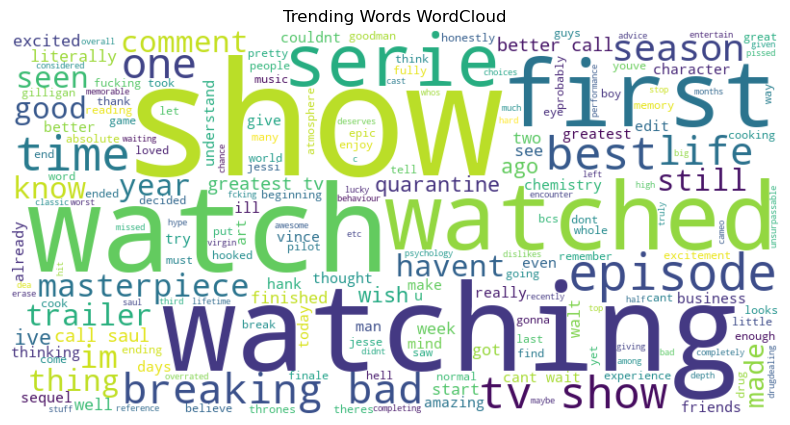

In [18]:
from wordcloud import WordCloud

all_words = " ".join(df["Cleaned"])

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color="white"
).generate(all_words)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Trending Words WordCloud")
plt.show()